# Software Development Lifecycle using Lang-Graph

In [1]:
import sys
print(sys.executable)

c:\Github\SDLC-using-Lang-Graph\env\Scripts\python.exe


In [2]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_openai import ChatOpenAI

In [6]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.types import Command, interrupt
import datetime

In [35]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
config = {"configurable": {"thread_id" : "101"}}

In [36]:
import sys
from pathlib import Path

# Go up one directory from "testing grounds" to the project root
project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [37]:
from tools.planner import planning
from tools.designer import designing
from tools.coder import coding
from tools.tester import testing

In [38]:
import importlib
import tools.coder

importlib.reload(tools.coder)
importlib.reload(tools.designer)
importlib.reload(tools.planner)
importlib.reload(tools.tester)

<module 'tools.tester' from 'c:\\Github\\SDLC-using-Lang-Graph\\tools\\tester.py'>

In [ ]:
graph_builder = StateGraph(State)

graph_builder.add_node("Planner", planning)
graph_builder.add_node("Designer", designing)
graph_builder.add_node("Coder", coding)
graph_builder.add_node("Tester", testing)


graph_builder.add_edge(START, "Planner")
graph_builder.add_edge("Planner", "Designer")
graph_builder.add_edge("Designer", "Coder")
graph_builder.add_edge("Coder", "Tester")
graph_builder.add_edge("Tester", "Coder")
graph_builder.add_edge("Tester", END)

graph = graph_builder.compile(checkpointer=memory)

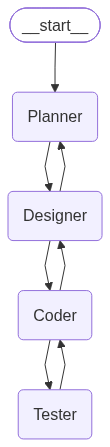

In [40]:
graph

In [41]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages" : [
    HumanMessage(content="""Create a **full-stack task management web application** called **TaskFlow**.

The application should have the following functionality:

### Core Requirements

1. Users should be able to create, edit, delete, and mark tasks as completed.
2. Each task should contain:

   * Title
   * Description
   * Priority: Low, Medium, High
   * Due date
   * Completion status
3. Users should be able to filter tasks by:

   * Completion status
   * Priority
   * Due date
4. Users should be able to search tasks by title.
5. Display separate sections for:

   * Pending tasks
   * Completed tasks
6. Show a simple dashboard containing:

   * Total tasks
   * Completed tasks
   * Pending tasks
   * High-priority tasks
7. The application should persist tasks between restarts.
8. Provide a clean and responsive UI that works on both desktop and mobile screens.

### Technical Requirements

* Build a frontend and backend.
* Use a REST API for communication between the frontend and backend.
* Use a database for persistent storage.
* Include proper input validation and error handling.
* Organize the code into logical modules/components.
* Include a requirements/dependency file for the project.
* Include instructions for running the application locally.

### Testing Requirements

The application should be tested for:

* Creating, editing, and deleting tasks.
* Invalid task input.
* Filtering and searching.
* Correct dashboard statistics.
* Persistence after restarting the application.
* API error handling.
* Frontend/backend integration.
* Edge cases such as empty task lists and duplicate-looking tasks.

### SDLC Process

Follow the SDLC architecture rather than simply generating the application directly.

1. **Planner**

   * Analyze the requirements.
   * Create or update `plan.md`.
   * Break the project into concrete development goals.
   * Define acceptance criteria and testing goals.

2. **Designer**

   * Use the planner's output.
   * Create or update `design.md`.
   * Define the application architecture, directory structure, API endpoints, database schema, frontend structure, dependencies, and important implementation decisions.
   * Do not implement the application.

3. **Implementor**

   * Use both `plan.md` and `design.md`.
   * Implement the application according to the requirements and design.
   * Create all required source files, configuration files, dependency files, and documentation.
   * Do not ignore the architecture defined by the Designer.

4. **Tester**

   * Inspect the implemented application.
   * Execute or generate meaningful tests based on the acceptance criteria.
   * Test both normal functionality and edge cases.
   * Report failures clearly, including the affected file/function and the expected vs actual behavior.
   * If something is incorrect, provide the test results back to the Implementor so it can make the necessary corrections.

The agents should **actually perform their respective tasks and modify the workspace/files when appropriate**, rather than merely describing what they would do.

The final workspace should contain a working application, `plan.md`, `design.md`, tests, dependencies, and a README explaining how to run the project.

Do not skip an SDLC stage unless the architecture determines that the stage is genuinely unnecessary.
"""),
    
]},config=config
)

Reading workspace.......
Reading artifacts.......
Writing code into workspace\artifacts\plan.md......
Writing code into workspace\artifacts\test.md......
Code succesfully written into workspace\artifacts\plan.md
Code succesfully written into workspace\artifacts\test.md
Writing code into workspace\artifacts\design.md......
Code succesfully written into workspace\artifacts\design.md
Writing code into workspace\artifacts\plan.md......
Code succesfully written into workspace\artifacts\plan.md


AttributeError: 'str' object has no attribute 'exists'

In [19]:
for m  in response["messages"]:
    m.pretty_print()

NameError: name 'response' is not defined